# 🧠 Deep Learning from Scratch / Section 5
# Recurrent Neural Networks (RNN)
---
**Builds on:** Sections 1–3  
**Goal:** Implement an RNN cell, BPTT, and train it to predict a time series.

---
## 📌 Table of Contents
1. [Intuition](#intuition)
2. [Mathematical Formulation](#math)
3. [RNN Cell Implementation](#cell)
4. [Forward Propagation Through Time](#forward)
5. [Backpropagation Through Time (BPTT)](#bptt)
6. [Gradient Clipping](#clip)
7. [Experiment: Sine-Wave Prediction](#exp)


## 1. Intuition <a id="intuition"></a>

### The Memory Problem

An MLP is **memoryless** : it processes each input independently. But language, music, and time-series have **temporal dependencies**: what comes next depends on what came before.

### The RNN Solution

An RNN maintains a **hidden state** $h_t$ : a compressed memory of the past. At each time step:
1. Read the new input $x_t$
2. Combine with previous memory $h_{t-1}$
3. Update memory → $h_t$
4. Optionally produce output $\hat{y}_t$

```
    x₁ → [cell] → h₁ ──►
                    ↑ (recurrent)
    x₂ → [cell] → h₂ ──►
                    ↑
    x₃ → [cell] → h₃ → ŷ
```

**Crucial:** the **same weights** are used at every time step — this is called **weight tying** and means the number of parameters doesn't grow with sequence length.


## 2. Mathematical Formulation <a id="math"></a>

### Hidden state update (Elman RNN)
$$h_t = \tanh\left( W_{xh}\, x_t + W_{hh}\, h_{t-1} + b_h \right)$$

### Output (optional, at each step)
$$\hat{y}_t = W_{hy}\, h_t + b_y$$

### Parameters
| Symbol | Shape | Meaning |
|---|---|---|
| $W_{xh}$ | (input_size, hidden_size) | Input → hidden |
| $W_{hh}$ | (hidden_size, hidden_size) | Hidden → hidden (recurrence) |
| $b_h$ | (1, hidden_size) | Hidden bias |
| $W_{hy}$ | (hidden_size, output_size) | Hidden → output |

### Why tanh?
- Output range $(-1, +1)$ — centred at 0, good for hidden states
- Smooth gradient everywhere
- In practice, LSTMs and GRUs replace this with gating mechanisms


## 3. RNN Cell Implementation <a id='cell'></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# ── Dark plot style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#3a3d4d",
    "axes.labelcolor":  "#c8ccd8",
    "xtick.color":      "#c8ccd8",
    "ytick.color":      "#c8ccd8",
    "text.color":       "#c8ccd8",
    "grid.color":       "#2a2d3d",
    "grid.alpha":       0.5,
    "legend.facecolor": "#1a1d27",
    "legend.edgecolor": "#3a3d4d",
    "font.family":      "monospace",
})

ACCENT = "#7c83ff"
GREEN  = "#56d364"
ORANGE = "#ffa657"
PINK   = "#f778ba"
YELLOW = "#e3b341"




✅ Setup complete — NumPy 2.0.2


In [2]:
# activation functions 

def relu(z):
  
    return np.maximum(0, z)

def relu_derivative(z):

    return (z > 0).astype(float)

def sigmoid(z):
    
    return np.where(z >= 0,
                    1 / (1 + np.exp(-z)),
                    np.exp(z) / (1 + np.exp(z)))

def sigmoid_derivative(z):
 
    s = sigmoid(z)
    return s * (1 - s)

def softmax(z):
   
    z_s   = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_s)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)




✅ Activation functions defined


In [3]:
class RNNCell:
    """
    Single Elman RNN cell.

    Forward:  hₜ = tanh( xₜ Wxh + hₜ₋₁ Whh + bh )
    Backward: gradients w.r.t. Wxh, Whh, bh, hₜ₋₁, xₜ
    """

    def __init__(self, input_size, hidden_size):
        scale = 0.01
        self.Wxh = np.random.randn(input_size,  hidden_size) * scale
        self.Whh = np.random.randn(hidden_size, hidden_size) * scale
        self.bh  = np.zeros((1, hidden_size))

    def forward(self, x_t, h_prev):
        """
        x_t    : shape (batch, input_size)
        h_prev : shape (batch, hidden_size)
        returns  h_t : shape (batch, hidden_size)
        """
        self.x_t    = x_t
        self.h_prev = h_prev
        # Pre-activation (stored for backward)
        self.z_t = x_t @ self.Wxh + h_prev @ self.Whh + self.bh
        # Apply tanh
        self.h_t = np.tanh(self.z_t)
        return self.h_t

    def backward(self, dh_t):
        """
        dh_t : upstream gradient for h_t
        Returns gradients for parameters and for h_{t-1} and x_t
        """
        # Gradient through tanh: d/dz tanh(z) = 1 - tanh²(z)
        dz = dh_t * (1 - self.h_t ** 2)

        dWxh  = self.x_t.T  @ dz
        dWhh  = self.h_prev.T @ dz
        dbh   = dz.sum(axis=0, keepdims=True)
        dx_t  = dz @ self.Wxh.T
        dh_prev = dz @ self.Whh.T

        return dx_t, dh_prev, dWxh, dWhh, dbh



✅ RNNCell defined


## 4 & 5. Forward + Backpropagation Through Time (BPTT) <a id="bptt"></a>

### BPTT Intuition
To compute gradients for the recurrent weights, we **unroll** the RNN across all $T$ time steps and apply backprop on the resulting (very deep) computation graph.

```
  x₁    x₂    x₃    ...    xₜ
   ↓     ↓     ↓             ↓
[cell]→[cell]→[cell]→ ... →[cell]→ ŷ → Loss
  h₁    h₂    h₃            hₜ
```

Gradients flow **backwards through time**: $\delta$ at step $t$ is influenced by all future steps $t+1, \ldots, T$.

### Truncated BPTT
For long sequences, full BPTT is expensive. In practice, we unroll for only $k$ steps at a time.


In [4]:
class SimpleRNN:
    """
    Many-to-one RNN:
        reads sequence of length T → produces single prediction.
    Used here for next-value forecasting.

    Architecture:
        RNNCell(input=1, hidden=32) → FC(32 → 1)
    """

    def __init__(self, input_size=1, hidden_size=32, output_size=1, lr=0.001):
        self.hidden_size = hidden_size
        self.lr          = lr
        self.cell        = RNNCell(input_size, hidden_size)
        self.Why         = np.random.randn(hidden_size, output_size) * 0.01
        self.by          = np.zeros((1, output_size))
        self.loss_hist   = []

    
    def forward(self, X_seq):
        """
        X_seq : shape (batch, T, input_size)
        Returns ŷ  : shape (batch, output_size)
        """
        batch, T, _ = X_seq.shape
        h = np.zeros((batch, self.hidden_size))

        self.h_states = [h]   # h_states[0] = h₀,  h_states[t] = hₜ
        self.x_inputs = []

        for t in range(T):
            x_t = X_seq[:, t, :]
            h   = self.cell.forward(x_t, h)
            self.h_states.append(h)
            self.x_inputs.append(x_t)

        self.h_last = h
        self.y_pred = h @ self.Why + self.by
        return self.y_pred

    def mse_loss(self, y_pred, y_true):
        return np.mean((y_pred - y_true) ** 2)


    def backward_through_time(self, y_true):
        """
        Backpropagation Through Time.
        Unroll backwards through all T steps, accumulating gradients.
        """
        T = len(self.x_inputs)
        batch = y_true.shape[0]

        # output layer gradients
        dy   = 2 * (self.y_pred - y_true) / batch    # dL/dŷ (MSE)
        dWhy = self.h_last.T @ dy
        dby  = dy.sum(0, keepdims=True)
        dh   = dy @ self.Why.T                         # gradient entering last hₜ

        # accumulate gradients across all time steps
        dWxh_acc = np.zeros_like(self.cell.Wxh)
        dWhh_acc = np.zeros_like(self.cell.Whh)
        dbh_acc  = np.zeros_like(self.cell.bh)

        for t in reversed(range(T)):
            # Restore cell state for step t
            self.cell.h_t    = self.h_states[t + 1]
            self.cell.h_prev = self.h_states[t]
            self.cell.x_t    = self.x_inputs[t]

            _, dh, dWxh, dWhh, dbh = self.cell.backward(dh)
            dWxh_acc += dWxh
            dWhh_acc += dWhh
            dbh_acc  += dbh

            # Gradient clipping prevents exploding gradients
            dh = np.clip(dh, -5, 5)

        # update all weights 
        clip = lambda g: np.clip(g, -5, 5)
        self.cell.Wxh -= self.lr * clip(dWxh_acc)
        self.cell.Whh -= self.lr * clip(dWhh_acc)
        self.cell.bh  -= self.lr * clip(dbh_acc)
        self.Why      -= self.lr * clip(dWhy)
        self.by       -= self.lr * clip(dby)

    def fit(self, X_seq, y_seq, n_epochs=300):
        for epoch in range(n_epochs):
            y_pred = self.forward(X_seq)
            loss   = self.mse_loss(y_pred, y_seq)
            self.loss_hist.append(loss)
            self.backward_through_time(y_seq)

            if (epoch + 1) % 50 == 0:
                print(f"  Epoch {epoch+1:4d}/{n_epochs}  MSE = {loss:.6f}")
        return self




✅ SimpleRNN with BPTT defined


## 6. Gradient Clipping <a id="clip"></a>

In RNNs, gradients can **explode** exponentially as they flow backwards through many time steps (since $W_{hh}$ is multiplied at each step).

**Gradient clipping** caps the gradient norm:
$$\text{if } \|\nabla\| > \text{threshold}: \quad \nabla \leftarrow \nabla \cdot \frac{\text{threshold}}{\|\nabla\|}$$

This prevents training from diverging without eliminating the gradient entirely.

Modern architectures (LSTM, GRU) address the related **vanishing gradient** problem through gating mechanisms.


## 7. Experiment: Sine-Wave Prediction <a id='exp'></a>

In [5]:
t_vals = np.linspace(0, 8 * np.pi, 1000)
series = np.sin(t_vals) + 0.05 * np.random.randn(len(t_vals))


seq_len = 20

def make_sequences(series, seq_len):
    X_list, y_list = [], []
    for i in range(len(series) - seq_len):
        X_list.append(series[i : i + seq_len])
        y_list.append(series[i + seq_len])
    X = np.array(X_list)[:, :, None]   # (N, T, 1)
    y = np.array(y_list)[:, None]      # (N, 1)
    return X, y

X_rnn, y_rnn = make_sequences(series, seq_len)

# Normalise to zero mean, unit std
X_mean, X_std = X_rnn.mean(), X_rnn.std()
X_rnn_n = (X_rnn - X_mean) / X_std
y_rnn_n = (y_rnn - X_mean) / X_std

print(f"Sequences: X={X_rnn_n.shape}, y={y_rnn_n.shape}")

# ── Train ─────────────────────────────────────────────────────────────────────
rnn = SimpleRNN(input_size=1, hidden_size=32, output_size=1, lr=0.001)
rnn.fit(X_rnn_n, y_rnn_n, n_epochs=300)


Sequences: X=(980, 20, 1), y=(980, 1)
  Epoch   50/300  MSE = 0.997425
  Epoch  100/300  MSE = 0.996220
  Epoch  150/300  MSE = 0.994907
  Epoch  200/300  MSE = 0.993433
  Epoch  250/300  MSE = 0.991739
  Epoch  300/300  MSE = 0.989757


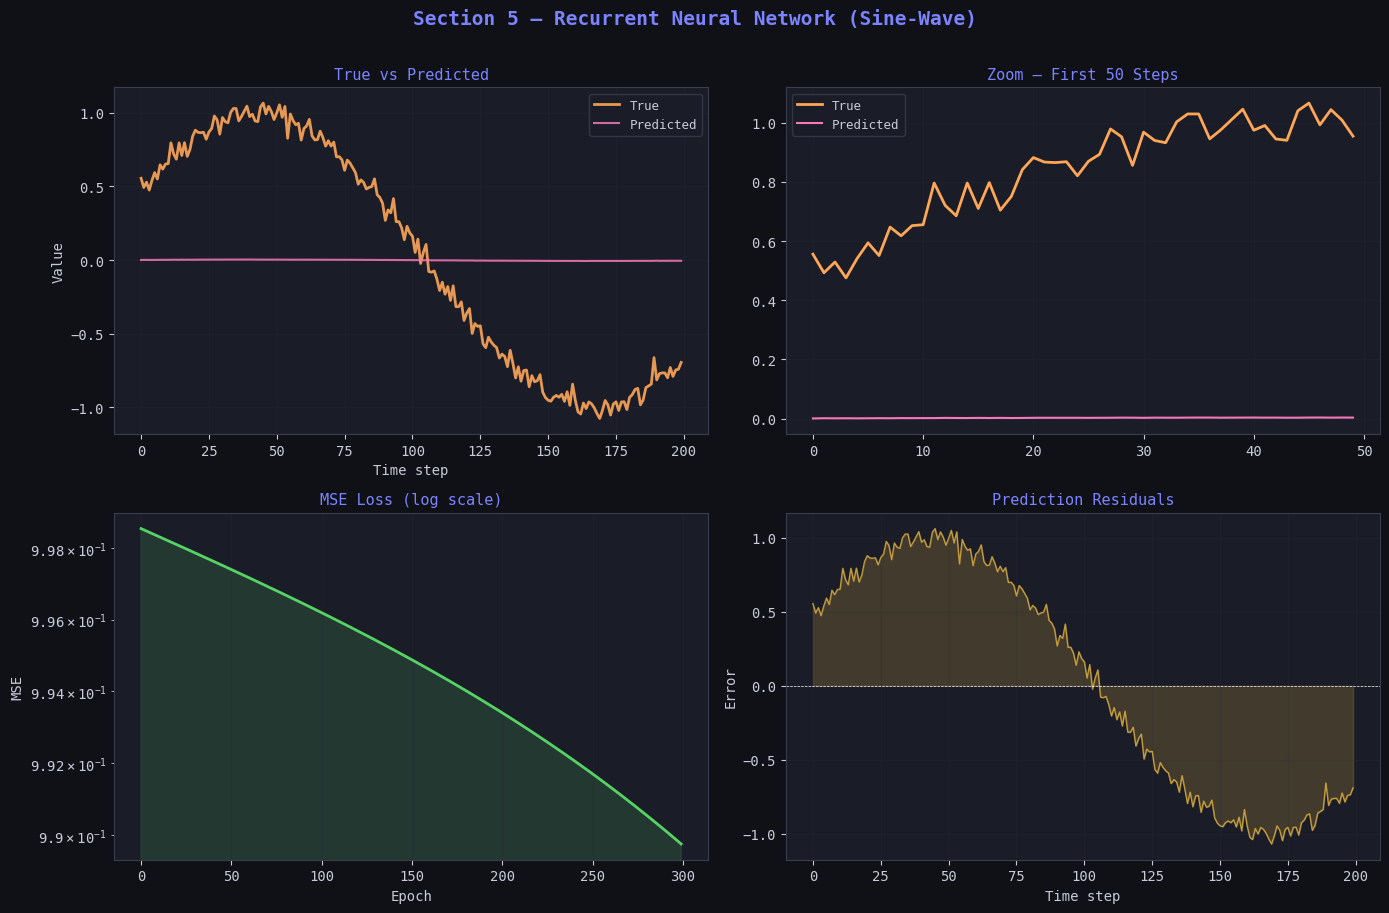

In [6]:
y_pred = rnn.forward(X_rnn_n) * X_std + X_mean


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("Section 5 — Recurrent Neural Network (Sine-Wave)", fontsize=14,
             color=ACCENT, fontweight="bold", y=1.01)

# Prediction overlay (first 200 steps)
ax = axes[0, 0]
ax.set_facecolor("#1a1d27")
ax.set_title("True vs Predicted", color=ACCENT, fontsize=11)
ax.plot(y_rnn[:200],  color=ORANGE, lw=2,   label="True",      alpha=0.9)
ax.plot(y_pred[:200], color=PINK,   lw=1.5, label="Predicted", alpha=0.85)
ax.legend(fontsize=9); ax.set_xlabel("Time step"); ax.set_ylabel("Value")
ax.grid(True, alpha=0.3)

# Zoom
ax2 = axes[0, 1]
ax2.set_facecolor("#1a1d27")
ax2.set_title("Zoom — First 50 Steps", color=ACCENT, fontsize=11)
ax2.plot(y_rnn[:50],  color=ORANGE, lw=2,   label="True")
ax2.plot(y_pred[:50], color=PINK,   lw=1.5, label="Predicted")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# Loss (log scale to show convergence detail)
ax3 = axes[1, 0]
ax3.set_facecolor("#1a1d27")
ax3.set_title("MSE Loss (log scale)", color=ACCENT, fontsize=11)
ax3.plot(rnn.loss_hist, color=GREEN, lw=2)
ax3.fill_between(range(len(rnn.loss_hist)), rnn.loss_hist, alpha=0.15, color=GREEN)
ax3.set_xlabel("Epoch"); ax3.set_ylabel("MSE")
ax3.set_yscale("log"); ax3.grid(True, alpha=0.3)

# Residuals
ax4 = axes[1, 1]
ax4.set_facecolor("#1a1d27")
ax4.set_title("Prediction Residuals", color=ACCENT, fontsize=11)
residuals = y_rnn.ravel() - y_pred.ravel()
ax4.plot(residuals[:200], color=YELLOW, lw=1, alpha=0.8)
ax4.axhline(0, color="white", lw=0.5, linestyle="--")
ax4.fill_between(range(200), residuals[:200], alpha=0.2, color=YELLOW)
ax4.set_xlabel("Time step"); ax4.set_ylabel("Error"); ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 🔑 Key Takeaways

| Concept | Detail |
|---|---|
| **Hidden state** | Compressed memory of the past |
| **Weight tying** | Same weights at every time step |
| **BPTT** | Unroll in time, apply standard backprop |
| **Exploding gradients** | $W_{hh}^T$ is multiplied at each step → exponential growth |
| **Gradient clipping** | Caps gradient norm — quick fix for exploding gradients |
| **Vanishing gradients** | Information from far-past steps fades → LSTM/GRU solve this |

---
## 🎓 Course Complete!

You have now implemented **from scratch in pure NumPy**:

| Section | Topic | Key Ideas |
|---|---|---|
| 1 | Perceptron | Step function, online update rule, linear boundary |
| 2 | MLP | He init, ReLU, Softmax, mini-batch SGD, cross-entropy |
| 3 | Backpropagation | Chain rule, δ-deltas, gradient flow, XOR |
| 4 | CNN | Convolution, im2col, max pooling, feature maps |
| 5 | RNN | Hidden state, BPTT, gradient clipping, sequence modelling |

**Next steps to explore:**
- LSTM / GRU (gated recurrent units)
- Batch Normalisation
- Attention & Transformers
- Adam / RMSProp optimisers
